# Assignment 2.1 — Return Distributions
**Phase 2 | Python for Finance Roadmap**

---

## The Scenario

You have daily price data for 5 assets: SPY (US equities), TLT (long-duration US Treasuries), GLD (gold), HYG (high yield bonds), and USD/TRY (US dollar vs Turkish lira).

Before building any strategy or doing any analysis, a quant researcher always asks: **what does the return distribution of this asset actually look like?** Most financial models assume returns are normally distributed. Your job is to test that assumption and understand what it means when it breaks down.

---

## Your Tasks

1. **Load and compute log returns** — Load `asset_prices.csv`. Compute daily log returns for all 5 assets. Why log returns and not simple returns?
2. **Plot histograms** — For each asset, plot a histogram of daily log returns. Overlay a normal distribution curve with the same mean and standard deviation. What do you notice?
3. **Compute descriptive statistics** — For each asset compute: mean, standard deviation, skewness, and kurtosis. Put them in a clean summary DataFrame.
4. **Fat tails** — Which assets are most fat-tailed? Which are most skewed? What does that mean for a risk manager?
5. **Annualize** — Convert daily mean return and daily volatility to annualized figures. Plot a risk/return scatter.
6. **EWMA vs Simple Rolling Volatility** — Compare exponentially weighted moving average volatility to a simple rolling window volatility. Which is more responsive and why does it matter?

---

## A Note Before You Start

Don't just compute numbers — interpret them in every markdown cell. A number without context is useless.

---

## Step 1 — Load and Compute Log Returns

*Load the prices CSV and compute daily log returns. Before writing code — why do we use log returns instead of simple returns in finance?*

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load prices

df = pd.read_csv('asset_prices.csv', index_col='Date', parse_dates=True)

df


,SPY,TLT,GLD,HYG,USD_TRY
Date,,,,,
2015-01-02,203.80,119.54,116.98,85.05,2.5148
2015-01-05,202.47,119.48,117.49,85.40,2.5063
2015-01-06,201.34,117.11,117.62,84.77,2.5821
2015-01-07,198.99,118.94,115.59,85.24,2.5758
2015-01-08,201.03,116.95,115.31,84.99,2.5807
...,...,...,...,...,...
2024-12-25,1023.22,82.27,127.12,237.07,10.9304
2024-12-26,1024.48,82.38,127.74,237.62,11.0375
2024-12-27,1012.72,82.26,126.80,235.79,11.1485


In [14]:
df.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2024-12-18', '2024-12-19', '2024-12-20', '2024-12-23',
               '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=2608, freq=None)

In [15]:
# Compute log returns for all columns at once

cols = ['SPY', 'TLT', 'GLD', 'HYG', 'USD_TRY']

df_log = np.log(df[cols] / df[cols].shift(1))
df_log


,SPY,TLT,GLD,HYG,USD_TRY
Date,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN
2015-01-05,-0.006547,-0.000502,0.004350,0.004107,-0.003386
2015-01-06,-0.005597,-0.020035,0.001106,-0.007404,0.029795
2015-01-07,-0.011740,0.015506,-0.017410,0.005529,-0.002443
2015-01-08,0.010200,-0.016873,-0.002425,-0.002937,0.001901
...,...,...,...,...,...
2024-12-25,0.012974,0.011984,0.001417,0.006899,-0.010249
2024-12-26,0.001231,0.001336,0.004865,0.002317,0.009751
2024-12-27,-0.011545,-0.001458,-0.007386,-0.007731,0.010006


**Why log returns instead of simple returns? Write your answer here.**

Because in simple math, going up and then go down by 10% would actually result in a loss ($100 -> $110 -> $99) but if you add the returns, it is 0% although it should be -1%. So the return calculation needs to account for that. Log returns don't have that problem, because they are additive. ln(110/100) + ln (98/100) results in -0.001005, which is a lot closer to true returns than simple return.

Additionally, log returns are symmetric for gains and losses and align better with continuous compounding assumptions used in finance.

---
## Step 2 — Plot Histograms with Normal Overlay

*For each asset, plot a histogram and overlay a normal distribution curve. Put all 5 plots in one figure.*

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

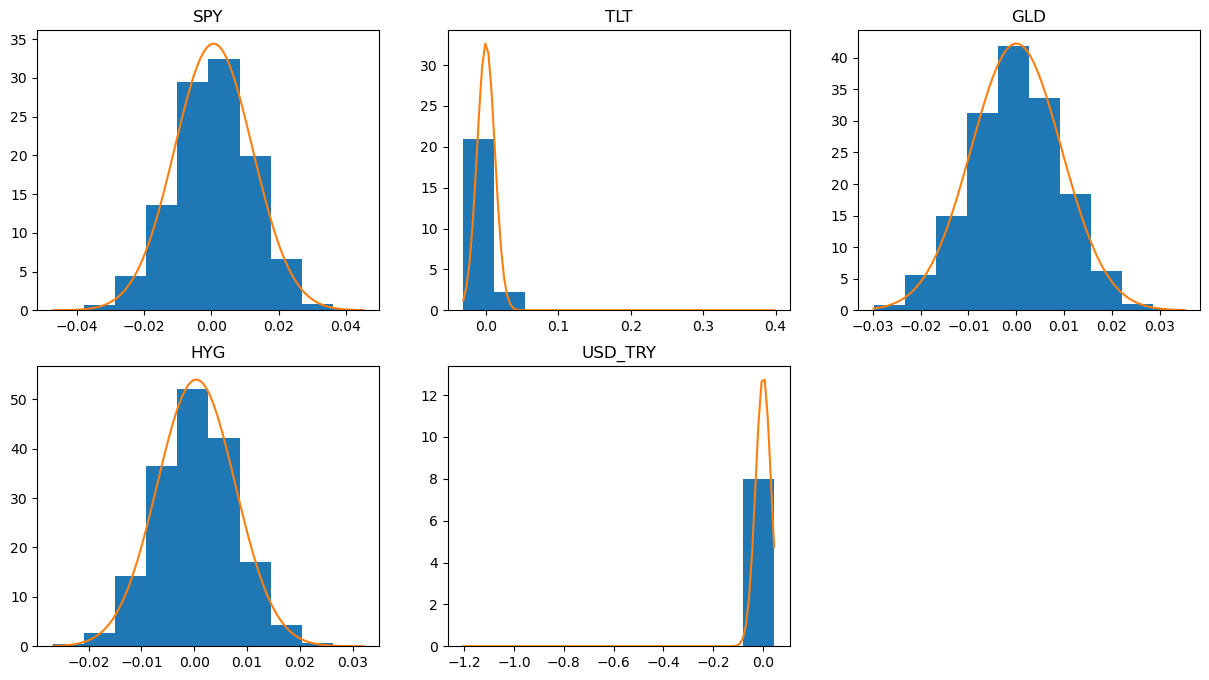

In [16]:
# Plot histograms with normal overlay
# Hint: use plt.subplots() for a grid of plots
# Hint: scipy.stats.norm.pdf() gives you the normal curve

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    mu = df_log[col].mean()
    sigma = df_log[col].std()
    x = np.linspace(df_log[col].min(), df_log[col].max(), 100)
    y = stats.norm.pdf(x, mu, sigma)
    axes[i].hist(df_log[col] , density = True)
    axes[i].plot(x,y)
    axes[i].set_title(col)


axes[-1].axis('off')


**What do you notice visually? Which assets look least normal? Where do the tails diverge most from the normal curve?**

SPY, GLD and HYG appear to be relatively symmetrical and have normal distribution over the 10-year period.

TLT has most data packed near negative to 0, but have a few large positive returns towards right, indicating right skew and non-normal distribution.

USD_TRY is the asset with the most non-normal distribution, most values near 0 with a dominant stretch in negative area.

---
## Step 3 — Descriptive Statistics

*Compute mean, std, skewness, and kurtosis for each asset. Present as a clean summary DataFrame.*

In [24]:
# Compute stats and build summary table
# Hint: pandas has .skew() and .kurt() built 

df_summary = {}

for col in cols:
    df_summary[col] = {
        'mean' : df_log[col].mean(),
        'std'  : df_log[col].std(),
        'skew' : df_log[col].skew(),
        'kurt' : df_log[col].kurt()
}

df_summary = pd.DataFrame(df_summary)


,SPY,TLT,GLD,HYG,USD_TRY
mean,0.000617,-0.000143,0.000032,0.000387,0.000571
std,0.011591,0.012200,0.009445,0.007391,0.030769
skew,-0.072558,13.353277,0.013600,0.026608,-29.534656
kurt,0.075618,434.855743,-0.042397,0.026972,1066.693238


**Which asset has the highest kurtosis? Which is most skewed? What does each mean in plain English?**

USD_TRY and then TLT has the highest kurosis and the skew as expected based on the plots we see previously.

Skew signals asymmetry, the higher the value, it means the tail is longer. So USD_TRY has a longer left tails while TLT has a longer right tail. In reality, for USD_TRY, it means that there were significant drops in lira (e.g. lira crises over the years) that were consistent and extreme relative to increases.

Kurtosis signals how extreme sudden changes happen compared to normal distribution. Considering that normal distribution has a kurtosis of 3, TLT (434) and USD_TRY (1066) have extremely thick tails. This signals that these asset classes are subject to extreme moves a lot more frequently than a normal distriribution (gold, HYG





---
## Step 4 — Fat Tails

*A normal distribution has kurtosis of 3. Anything above 3 means fatter tails than normal (excess kurtosis > 0).*

In [25]:
# Compute excess kurtosis (kurtosis - 3) for each asset

# Pandas kurtosis is already deducts 3, so the kurtosis data below already is excess kurtosis.

df_summary





,SPY,TLT,GLD,HYG,USD_TRY
mean,0.000617,-0.000143,0.000032,0.000387,0.000571
std,0.011591,0.012200,0.009445,0.007391,0.030769
skew,-0.072558,13.353277,0.013600,0.026608,-29.534656
kurt,0.075618,434.855743,-0.042397,0.026972,1066.693238


**If you were building a VaR model assuming normal distributions, which asset would your model be most wrong about? Why does this matter?**

So, if we used VaR to test the risk, VaR for TLT and USD_TRY would be substantially underestimated because risk would be far greater. In other words, if Var indicated no more losses of "x" on 95% of days, we could have ended up with 2x, or even 3x losses during black swan days.


---
## Step 5 — Annualize and Plot Risk/Return

*Convert daily mean return and daily volatility to annualized figures. There are 252 trading days in a year.*

In [19]:
# Annualize returns and volatility
# Hint: annualized return = daily mean * 252
# Hint: annualized vol = daily std * sqrt(252)

df_summary.loc['return'] = df_summary.loc['mean'] * 252
df_summary.loc['vol'] = df_summary.loc['std'] * np.sqrt(252)


df_summary



,SPY,TLT,GLD,HYG,USD_TRY
mean,0.000617,-0.000143,0.000032,0.000387,0.000571
std,0.011591,0.012200,0.009445,0.007391,0.030769
skew,-0.072558,13.353277,0.013600,0.026608,-29.534656
kurt,0.075618,434.855743,-0.042397,0.026972,1066.693238
return,0.155498,-0.036035,0.008035,0.097607,0.143773
vol,0.183998,0.193664,0.149929,0.117324,0.488445


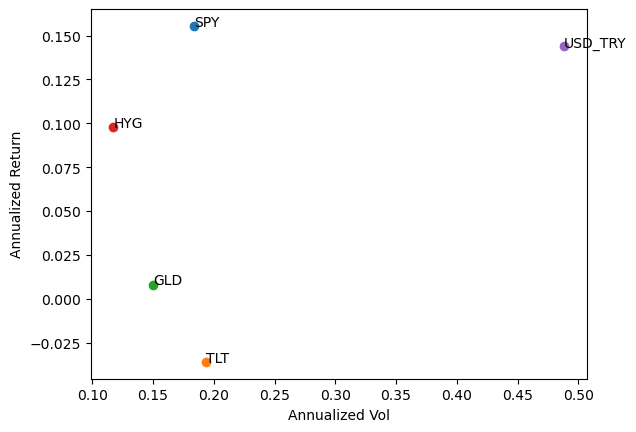

In [20]:
# Plot risk/return scatter: x = annualized vol, y = annualized return
# Label each point with the asset name

for col in cols:
    plt.scatter(df_summary.loc['vol', col], df_summary.loc['return', col])
    plt.text(df_summary.loc['vol', col], df_summary.loc['return', col], col)

plt.xlabel('Annualized Vol')
plt.ylabel('Annualized Return')
plt.show()

**Which asset has the best risk-adjusted return? Which has the worst? Does anything surprise you?**

Based on the graph HYG and SPY looks to have strong risk-adjusted returns but only sharpe ratio could determine which is higher. I calculated sharpe ratio below, and it appears SPY has the best risk-adjusted returns while TLT has the worst returns.

It is not surprising, but interesting to see that TLT has a similar volatility but considerably lower returns (it's the only asset class with negative returns).


In [9]:
df_summary.loc['sharpe'] = df_summary.loc['return'] / df_summary.loc['vol']
df_summary

,SPY,TLT,GLD,HYG,USD_TRY
mean,0.000617,-0.000143,0.000032,0.000387,0.000571
std,0.011591,0.012200,0.009445,0.007391,0.030769
skew,-0.072558,13.353277,0.013600,0.026608,-29.534656
kurt,0.075618,434.855743,-0.042397,0.026972,1066.693238
return,0.155498,-0.036035,0.008035,0.097607,0.143773
vol,0.183998,0.193664,0.149929,0.117324,0.488445
sharpe,0.845107,-0.186071,0.053595,0.831947,0.294349


---
## Step 6 — EWMA vs Simple Rolling Volatility

*Simple rolling volatility weights every day in the window equally — a crash 89 days ago counts the same as yesterday. Exponentially Weighted Moving Average (EWMA) gives more weight to recent observations. This step explores why that matters.*

In [10]:
df_log

,SPY,TLT,GLD,HYG,USD_TRY
Date,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN
2015-01-05,-0.006547,-0.000502,0.004350,0.004107,-0.003386
2015-01-06,-0.005597,-0.020035,0.001106,-0.007404,0.029795
2015-01-07,-0.011740,0.015506,-0.017410,0.005529,-0.002443
2015-01-08,0.010200,-0.016873,-0.002425,-0.002937,0.001901
...,...,...,...,...,...
2024-12-25,0.012974,0.011984,0.001417,0.006899,-0.010249
2024-12-26,0.001231,0.001336,0.004865,0.002317,0.009751
2024-12-27,-0.011545,-0.001458,-0.007386,-0.007731,0.010006


In [11]:
# Compute for SPY:
# 1. Simple rolling 60-day volatility (annualized)
# 2. EWMA volatility with span=60 (annualized)
# Hint: pandas has .rolling().std() and .ewm().std()

simple_rolling = df_log['SPY'].rolling(60).std()
EWMA_rolling = df_log['SPY'].ewm(span = 60).std()

print(simple_rolling, EWMA_rolling)



Date
2015-01-02         NaN
2015-01-05         NaN
2015-01-06         NaN
2015-01-07         NaN
2015-01-08         NaN
                ...   
2024-12-25    0.011971
2024-12-26    0.011950
2024-12-27    0.011918
2024-12-30    0.011746
2024-12-31    0.011671
Name: SPY, Length: 2608, dtype: float64 Date
2015-01-02         NaN
2015-01-05         NaN
2015-01-06    0.000672
2015-01-07    0.003338
2015-01-08    0.009646
                ...   
2024-12-25    0.012207
2024-12-26    0.012006
2024-12-27    0.011997
2024-12-30    0.011799
2024-12-31    0.011640
Name: SPY, Length: 2608, dtype: float64


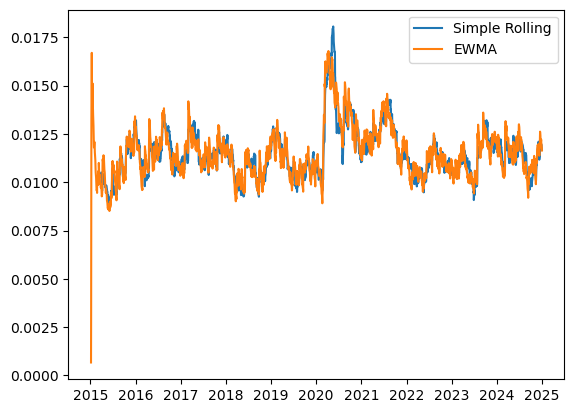

In [12]:
plt.plot(simple_rolling, label='Simple Rolling')
plt.plot(EWMA_rolling, label='EWMA')
plt.legend()
plt.show()


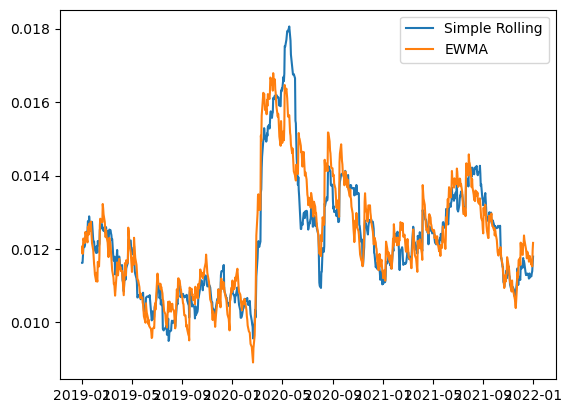

In [28]:
plt.plot(simple_rolling['2019':'2021'], label='Simple Rolling')
plt.plot(EWMA_rolling['2019':'2021'], label='EWMA')
plt.legend()
plt.show()

**Which measure reacts faster to the COVID crash? Which takes longer to come back down after the crash? Why would a risk manager prefer EWMA over a simple rolling window?**

EWMA reacs faster to Covid crash as it pleces more weight on recent observations while simple rolling windows gives equal weight to all observations.

After the volatility spike, the simple rolling measure tends to stay elevated longer. EWMA decays those observations over time, which adjusts downward faster.

A risk manager'd prefer EWMA due to more responsive mechanism to changing market and risk conditions and captures shorter term volatility trends more effectively.

---
## Wrap-Up

Write 3-4 sentences as if summarizing findings to a portfolio manager. What did you learn about these 5 assets from their return distributions? What assumption would be dangerous to make?


Each asset behaved differently across macro regimes. TLT posted negative returns as higher inflation expectations drove yields higher, hurting the price of long duration bonds. USD/TRY was by far the most vlolatile class, demonstrating multiple currency crises in Turkey as inflation accelerated while central bank lowered interest rates.
HYG ended up producing a strong risk-adjusted return and traded like an equity instrument vs. a fixed income given the credit exposure. SPY also benefited from low-rate environment.
    One important assumption that's dangerous to make is assuming normality for TLT USD/TRY. With kurtosis above 400 and 1000 respectively, a VaR framework would underestimate tail risk.
    